In [8]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle

from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


In [ ]:
t1_str = '2025-08-14'
t2_str = '2025-08-22'

# if the 1st argument below is False, then we get the most recent 7 days of data
# the last time stamp is about 1-2 hours before current time. Nice!
t,Q = riverfuns.get_observed_TJriver_flow(False,t1_str,t2_str)





File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv


2025-08-22 18:00:00


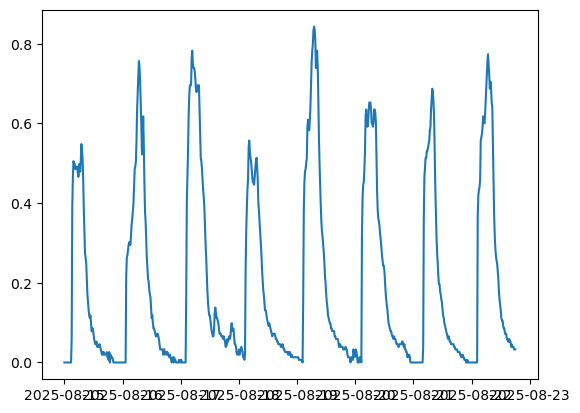

In [ ]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)


In [9]:
file_in = '/scratch/PFM_Simulations/LV4_Forecast/Forc/river_Q.pkl'
with open(file_in,'rb') as fp:
    NWM = pickle.load(fp)

t_nwm = NWM['time']
q_nwm = NWM['discharge'][:,2]


In [38]:
#t_fore = t_nwm[0]
tf_dt = t_nwm[0] #datetime.strptime(t_fore,'%Y%m%d%H')
start_time = tf_dt - 1* timedelta(days=1)
end_time = tf_dt

# Create a boolean mask
# This directly compares datetime objects within the array
mask = (t >= start_time) & (t <= end_time)

    # Get the indices where the mask is True
indices = np.where(mask)[0]
    # take the mean over these indices
Qb1 = np.mean( Q[indices] )

mask2 = (Q<1.0)
i2 = np.where(mask2)[0]
Qb2 = np.mean( Q[i2] )

print(Qb1)
print(Qb2)

Qf_p = Qb1*np.ones(np.shape(t_nwm))
#print(np.shape(q_nwm))
#print(np.shape(Qf_p))
Qf_pnwm = Qf_p[:,0] + q_nwm - q_nwm[0]
dt = t_nwm - t_nwm[0]
dt_sec = []
for dtt in dt:
    dt_sec.append(dtt[0].total_seconds())
dt_day = np.array(dt_sec) / 3600 /24
tau_day = 1.5
alpha = np.exp(-dt_day / tau_day)
Q_new2 = Qf_p[:,0] * alpha + (1-alpha)*Qb2 
Q_new = Qf_p[:,0] * alpha + (1-alpha)*Qb2 + q_nwm - q_nwm[0]




0.16465141780116258
0.20513315114146208


2025-08-22 18:00:00


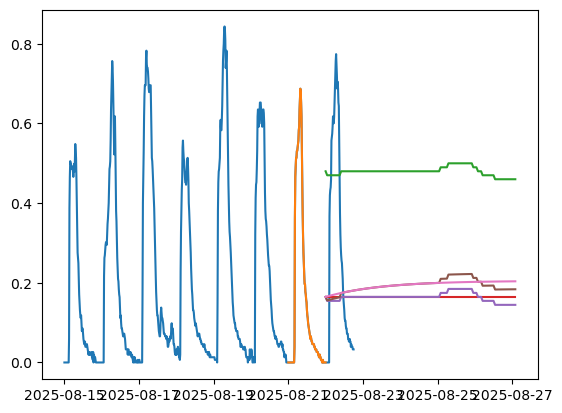

In [39]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)
ax.plot(t[indices],Q[indices])
ax.plot(t_nwm,q_nwm)
ax.plot(t_nwm,Qf_p)
ax.plot(t_nwm,Qf_pnwm)
ax.plot(t_nwm,Q_new)
ax.plot(t_nwm,Q_new2)

